In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

%matplotlib inline
import matplotlib.pyplot as plt

from functools import reduce
add = lambda x, y: x + y

In [2]:
dairy = pd.read_csv('dairy_dataset_extended.csv', parse_dates=
                    ['Date', 'Production_Date', 'Expiration_Date'])
dairy.sort_values(by='Production_Date', inplace=True)

print(np.abs(dairy.Quantity_liters_kg -\
    (dairy.Quantity_Sold_liters_kg + dairy.Quantity_in_Stock_liters_kg)).max())
print(np.abs(dairy.Total_Value -\
    dairy.Price_per_Unit * dairy.Quantity_liters_kg).max())
print(np.abs(dairy.Approx_Total_Revenue_INR -\
    dairy.Price_per_Unit_sold * dairy.Quantity_Sold_liters_kg).max())

0.9900000000000091
1.4551915228366852e-11
1.4551915228366852e-11


In [3]:
milk_data = dairy[dairy.Product_ID == 1]
milk_data.Brand.unique()

array(['Sudha', 'Raj', 'Amul', 'Mother Dairy'], dtype=object)

In [4]:
original_features =\
    ['Location', 'Total_Land_Area_acres', 'Number_of_Cows', 'Farm_Size',
     'Date', 'Product_ID', 'Product_Name', 'Brand', 'Quantity_liters_kg',
     'Price_per_Unit', 'Total_Value', 'Shelf_Life_days', 'Storage_Condition',
     'Production_Date', 'Expiration_Date', 'Quantity_Sold_liters_kg',
     'Price_per_Unit_sold', 'Approx_Total_Revenue_INR', 'Customer_Location',
     'Sales_Channel', 'Quantity_in_Stock_liters_kg',
     'Minimum_Stock_Threshold_liters_kg', 'Reorder_Quantity_liters_kg']

basic_features =\
    ['Total_Land_Area_acres', 'Number_of_Cows', 'Price_per_Unit',
     'Shelf_Life_days', 'Price_per_Unit_sold', 'Quantity_in_Stock_liters_kg',
     'Minimum_Stock_Threshold_liters_kg', 'Reorder_Quantity_liters_kg']

categorical_features =\
    ['Location', 'Farm_Size', 'Product_Name', 'Brand', 'Storage_Condition',
     'Production_Date', 'Customer_Location', 'Sales_Channel']

goal = 'Quantity_Sold_liters_kg'

In [5]:
default_xgbparams = dict(n_estimators=500, max_depth=10, learning_rate=0.1, random_state=42)

def test_features(features: list[str] = basic_features,
                  Model = XGBRegressor, params: dict = default_xgbparams,
                  make_plots: bool = False, R2_only: bool = True) -> None:
    # X = milk_data[features]
    # y = milk_data[goal]
    X = dairy[features]
    y = dairy[goal]
    X_train, X_test, y_train, y_test =\
        train_test_split(X, y, test_size=0.2, random_state=42)

    try:
        xgb_model = Model(**params)
        xgb_model.fit(X_train, y_train)
    except AttributeError:
        pass

    # https://medium.com/@emilykmarsh/xgboost-feature-importance-233ee27c33a4
    if make_plots:
        sorted_idx = xgb_model.feature_importances_.argsort()
        plt.barh(X.columns[sorted_idx], xgb_model.feature_importances_[sorted_idx])
        plt.xlabel("Xgboost Feature Importance")
        plt.show()

    y_pred = xgb_model.predict(X_test)
    if make_plots:
        plt.figure(figsize=(8, 6))
        plt.scatter(y_test, y_pred, alpha=0.6)
        plt.xlabel("Actual Quantity Sold")
        plt.ylabel("Predicted Quantity Sold")
        plt.title("XGBoost: Actual vs Predicted Sales")
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.show()

    # y_pred_xgb = xgb_model.predict(X_test)
    # naïve forecast for MASE
    naive_forecast = np.roll(y_test, shift=1)
    naive_forecast[0] = y_test.mean()
    # compute metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae_baseline = mean_absolute_error(y_test, naive_forecast)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    mase = mae / mae_baseline
    # report metrics
    print(f"R²: {r2:.6f}")
    if not R2_only:
        print(f"MAE: {mae:.6f}")
        print(f"MSE: {mse:.6f}")
        print(f"RMSE: {rmse:.6f}")
        print(f"MAPE: {mape:.6f}%")
        print(f"MASE: {mase:.6f}")

In [6]:
def check_recovery(features: list[str] = basic_features,
                   Model = XGBRegressor, params: dict = default_xgbparams,
                   make_plots: bool = False, R2_only: bool = True) -> None:
    X = dairy[features]
    y = dairy[goal]
    X_train, X_test, y_train, y_test =\
        train_test_split(X, y, test_size=0.2, random_state=42)

    try:
        xgb_model = Model(**params)
        xgb_model.fit(X_train, y_train)
    except AttributeError:
        pass

    y_pred = xgb_model.predict(X_train)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_train, y_pred, alpha=0.6)
    plt.xlabel("Actual Quantity Sold")
    plt.ylabel("Recovered Quantity Sold")
    plt.title("XGBoost: Actual vs Recovered Sales")
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    plt.show()

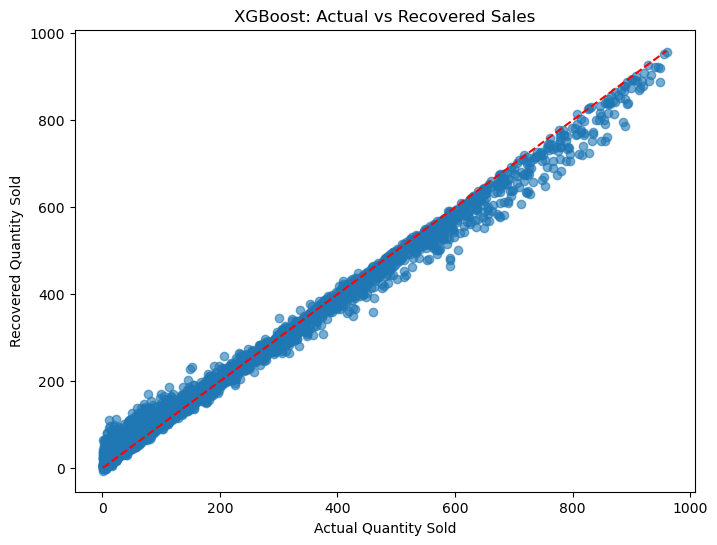

In [7]:
my_xgbparams = dict(n_estimators=300, max_depth=8, learning_rate=0.1, random_state=42)
check_recovery(params=my_xgbparams)

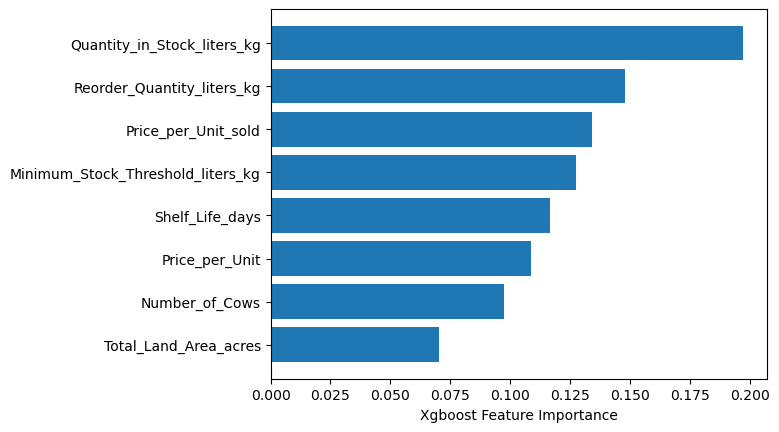

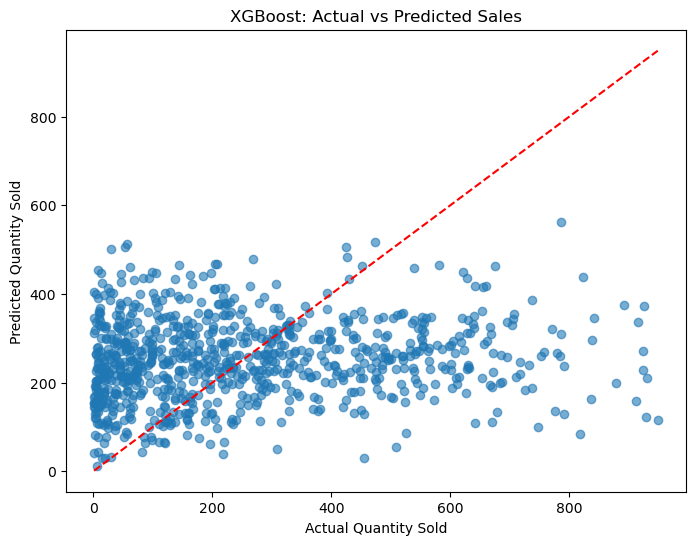

R²: -0.072102
MAE: 182.273849
MSE: 52140.785156
RMSE: 228.343568
MAPE: 628.960275%
MASE: 0.752781


In [8]:
test_features(params=my_xgbparams, make_plots=True, R2_only=False)

In [9]:
quarters = ['Quarter' + str(quarter) for quarter in range(1, 5)]
months = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

def rename_column(column: str) -> str:
    return ''.join(char if char.isalnum() else '_' for char in column)\
        .replace('__', '_').rstrip('_')

def binary_features(column: str) -> None:
    if 'Date' in column:
        return [column + '_' + suffix for suffix in (['Year'] + quarters)]
    return [column + '_' + rename_column(catagory)
            for catagory in dairy[column].unique()]

In [10]:
for column in categorical_features:
    print(column, end=': ')
    test_features(basic_features + binary_features(column),
                  params=my_xgbparams)

Location: R²: -0.029940
Farm_Size: R²: -0.055548
Product_Name: R²: -0.054010
Brand: R²: -0.046973
Storage_Condition: R²: -0.037781
Production_Date: R²: -0.050566
Customer_Location: R²: -0.050358
Sales_Channel: R²: -0.035215


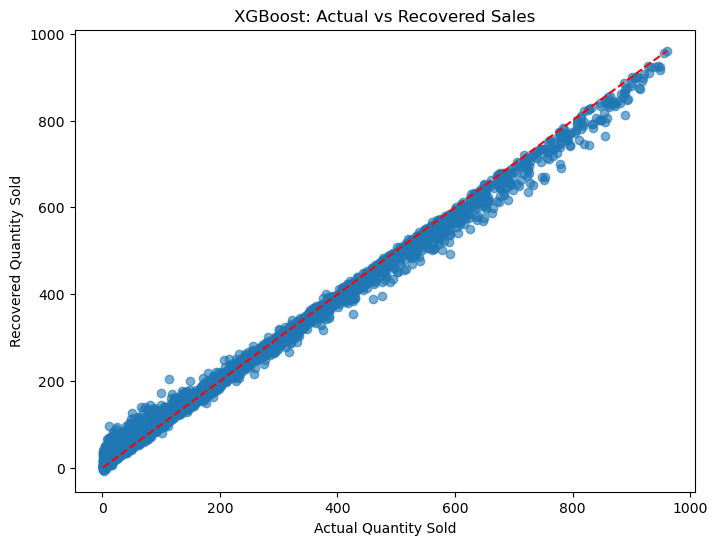

In [11]:
meaningful_features = basic_features + reduce(add, [binary_features(column)
    for column in ['Product_Name', 'Brand', 'Production_Date', 'Sales_Channel']])
check_recovery(meaningful_features, params=my_xgbparams)

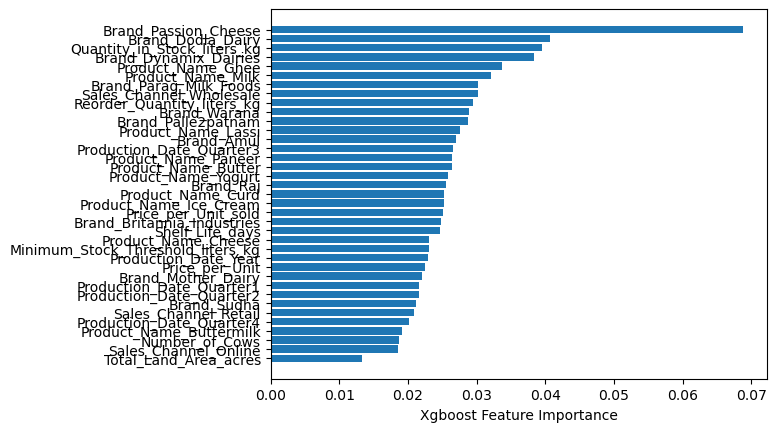

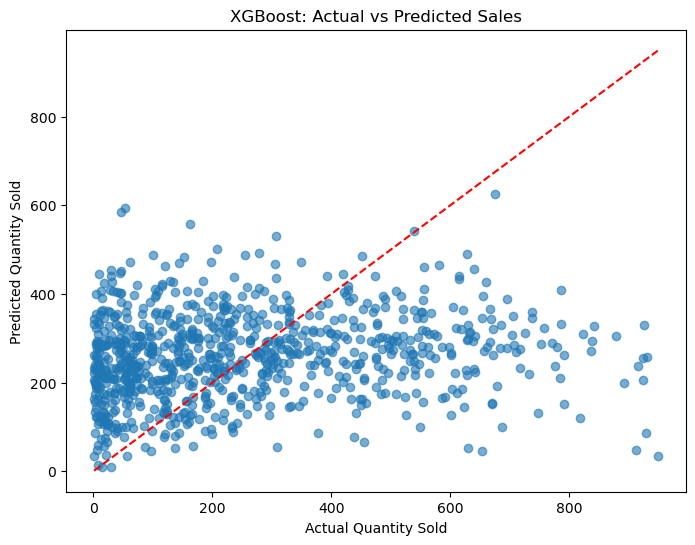

R²: -0.062817


In [12]:
test_features(meaningful_features, params=my_xgbparams, make_plots=True)